# Wannierisation (including SAWF)

This tutorial shows how to construct (Symmetry adapted) Wannier functions with WannierBerri, with magnetic symmetries. We will use the example of bcc Fe.

## 0. Compute QuantumEspresso files

in tthe tutorial repository only the input files for Quantum ESPRESSO are provided
to obtain the necessary files one needs to run
```
pw.x < Fe_pw_scf_in > Fe_pw_scf_out
pw.x < Fe_pw_nscf_in > Fe_pw_nscf_out
wannier90.x -pp Fe
pw2wannier90.x < Fe_pw2wan_in > Fe_pw2wan_out
```
 
## 1. Setup

First import modules and set up the parallel environment



In [1]:
import ray
# Initialize Ray with 8 CPU cores
# Do this only once at the beginning of your script. Initializing multiple times will lead to errors.
ray.init(num_cpus=8)
# If needed, you can do ray.shutdown() at the end of your script to clean up resources.

/home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-31 00:39:24,781	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-31 00:39:26,597	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8269 


Python version:,3.12.12
Ray version:,2.48.0
Dashboard:,http://127.0.0.1:8269


In [2]:

import os

from matplotlib import pyplot as plt
import scipy
import wannierberri as wb
import numpy as np

path_data = "./pwscf/"  # adjust path if needed to point to the data in the tests fo wannier-berri repository

assert os.path.exists(path_data), f"Path {path_data} does not exist"

import irrep, spglib

wb.welcome()


.::    .   .::: .:::::::.  :::.    :::.:::.    :::. :::.,::::::  :::::::..       :::::::.  .,::::::  :::::::..   :::::::..   :::
';;,  ;;  ;;;' '  ;;`;;  ` `;;;;,  `;;;`;;;;,  `;;; ;;;;;;;''''  ;;;;``;;;;       ;;;'';;' ;;;;''''  ;;;;``;;;;  ;;;;``;;;;  ;;;
 '[[, [[, [['    ,[[ '[[,    [[[[[. '[[  [[[[[. '[[ [[[ [[cccc    [[[,/[[['       [[[__[[\. [[cccc    [[[,/[[['   [[[,/[[['  [[[
   Y$c$$$c$P    c$$$cc$$$c   $$$ "Y$c$$  $$$ "Y$c$$ $$$ $$""""    $$$$$$c         $$""""Y$$ $$""""    $$$$$$c     $$$$$$c    $$$
    "88"888      888   888,  888    Y88  888    Y88 888 888oo,__  888b "88bo,    _88o,,od8P 888oo,__  888b "88bo, 888b "88bo,888
     "M "M"      YMM   ""`   MMM     YM  MMM     YM MMM """"YUMMM MMMM   "W"     ""YUMMMP"  """"YUMMM MMMM   "W"  MMMM   "W" MMM

Version: 26.3.3.dev2+g2858c459a


   HTTP://WANNIER-BERRI.ORG  

Checking dependencies …
irrep : 2.6.3
spglib : 2.6.0
numpy : 2.3.4
scipy : 1.16.2
spgrep : 0.3.11
numba : 0.62.1
pyfftw : 0.15.0
seekpath : 2.2.1
matplotlib : 

{'irrep': '2.6.3',
 'spglib': '2.6.0',
 'numpy': '2.3.4',
 'scipy': '1.16.2',
 'spgrep': '0.3.11',
 'numba': '0.62.1',
 'pyfftw': '0.15.0',
 'seekpath': '2.2.1',
 'matplotlib': '3.10.7',
 'sympy': '1.14.0',
 'fortio': '0.4',
 'gpaw': '25.7.0',
 'ase': '3.26.0',
 'pythtb': '1.8.0',
 'xmltodict': '1.0.2'}

## 2. Read the bandstructure from Quantum ESPRESSO

we use the Bnadstructure object form irrep to read the bandstructure from Quantum ESPRESSO. It also can be used to read from VASP, ABINIT, GPAW etc. , see documentation of irrep for more details.

In [3]:

from irrep.bandstructure import BandStructure
assert os.path.exists(path_data), f"Path {path_data} does not exist"
bandstructure = BandStructure(code='espresso',   # to work with VASP or abinit please refer to the documentation of irrep
                            prefix=os.path.join(path_data, "Fe"),
                            magmom=[[0,0,1]],  # set the magnetic moments for a magnetic system (units do not matter)
                            include_TR=True)  # set include_TR=False if you do not want to include the symmetries involving time reversal (magnetic symmetries)
spacegroup = bandstructure.spacegroup
# spacegroup.show() # uncomment to see the detected symmetries of the system

## 3. Create the "w90files"

Here we use the WannierData object, to create the eig, symmetrizer, and mmn file (see below)
Note - that are not actually files in w90 format, but some objects that contain the same information 


In [17]:
wandata = wb.w90files.WannierData.from_bandstructure(
    bandstructure=bandstructure,
    files = ["eig","symmetrizer", "mmn"] , # remove "mmn" if you do the next step (see below) 
    irreducible=False # if you do not use any files from the pw2wannier90, you may want to set irreducible=True to only use the irreducible k-points
)


got irreducible=False, mp_grid=None, seedname=wannier90, files=['eig', 'symmetrizer', 'mmn'],  projections=None, unk_grid=None, normalize=True
self.irreducible=False
mpgrid = [4 4 4], 64
Shells found with weights [0.41728408] and tolerance 7.693398823301265e-16
NK= 64, selected_kpoints = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63], kptirr = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


### 3.1 Read the mmn file from pw2wannier90 (if needed)

irrep only reads the plane wave coefficients of the wavefunctions, and not the projections (EXCEPT for GPAW). This is totally fine for the symmetrizer, and ok for the amn file, but is very inaccurate for the mmn file. 

This step is necessary if :

* QE/VAST/Abinit with ultrasoft or PAW pseudopotentials.

Not needed if:
* GPAW (projections are read by irrep)
* QE/VAST/Abinit with norm-conserving pseudopotentials (plane wave coefficients are sufficient to construct the mmn file in this case)

In [18]:
mmn = wb.w90files.mmn.MMN.from_w90_file(os.path.join(path_data,"Fe"), bkvec=wandata.bkvec)
wandata.set_file("mmn", mmn, overwrite=True)

/home/stepan/github/wannier-berri/wannierberri/w90files/wandata.py:639: UserWarning: file 'mmn' was already set, overwriting it
  warnings.warn(f"file '{key}' was already set, overwriting it")


### 3.2 Save the w90files with to npz for later use (optional)
You can save the created w90files to npz format for later use, to save time. Later thay can be loaded

In [19]:
wandata.to_npz(os.path.join(path_data,"Fe_w90data"))
wandata_loaded = wb.w90files.WannierData.from_npz(os.path.join(path_data,"Fe_w90data"), 
                                                files=["eig","symmetrizer", "mmn"])

saving to ./pwscf/Fe_w90data.sawf.npz : 
saving to ./pwscf/Fe_w90data.bkvec.npz : 
saving to ./pwscf/Fe_w90data.chk.npz : 
saving to ./pwscf/Fe_w90data.eig.npz : 
saving to ./pwscf/Fe_w90data.mmn.npz : 
files = ['eig', 'symmetrizer', 'mmn', 'bkvec']
Trying to read file eig from npz ./pwscf/Fe_w90data.eig.npz
setting file eig from npz ./pwscf/Fe_w90data.eig.npz as <wannierberri.w90files.eig.EIG object at 0x79a4dc5ac1a0>
Trying to read file symmetrizer from npz ./pwscf/Fe_w90data.symmetrizer.npz
setting file symmetrizer from npz ./pwscf/Fe_w90data.sawf.npz as <wannierberri.symmetry.sawf.SymmetrizerSAWF object at 0x79a6b9a55130>
Trying to read file mmn from npz ./pwscf/Fe_w90data.mmn.npz
setting file mmn from npz ./pwscf/Fe_w90data.mmn.npz as <wannierberri.w90files.mmn.MMN object at 0x79a4dc655d60>
Trying to read file bkvec from npz ./pwscf/Fe_w90data.bkvec.npz
setting file bkvec from npz ./pwscf/Fe_w90data.bkvec.npz as <wannierberri.w90files.bkvectors.BKVectors object at 0x79a6b9d0fd10>


## 4 Choose projections

This is similar to wannier90. However, in this case the projections already include the symmetry information. 

'position_num' may contain only one position of the ornit, in this case the others will be generated by symmetry. However, this should be used with caution, as the generated positions may differ by a lattice vector, which may cause problems in some cases.

### 4.1 set the amn and symmetry of future Wannier functions

The last line serves two purposes: 
1. creates and sets the amn file - initial guess for the Wannier functions
2. sets how the Wannier functions should transform under the symmetry operations.

Both are based on the `projections_set` object.

In [20]:

from wannierberri.symmetry.projections import Projection, ProjectionsSet
# now set the transformations of WFs. Make sure, the projections are consistent with the amn file
proj_s = Projection(position_num = [[0,0,0]], orbital='s', spacegroup=spacegroup)
proj_p = Projection(position_num = [[0,0,0]], orbital='p', spacegroup=spacegroup)
proj_d = Projection(position_num = [[0,0,0]], orbital='d', spacegroup=spacegroup)
projections_set = ProjectionsSet(projections=[proj_s, proj_p, proj_d])
wandata.set_projections(projections_set, bandstructure=bandstructure)


Setting AMN with kwargs={'kptirr': array([ 0,  1,  2,  4,  6,  7,  8, 21, 22, 23, 27, 29, 42]), 'NK': 64, 'selected_kpoints': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])}
finding num points from 3 projections
finding num points from 3 projections
Creating amn. Using projections_set 
ProjectionsSet with 18 Wannier functions and 0 free variables
Projection 0, 0, 0:['s'] with 2 Wannier functions (1 per spin x2 spins) 
 on 1 points (2 per site)
Projection 0, 0, 0:['p'] with 6 Wannier functions (3 per spin x2 spins) 
 on 1 points (6 per site)
Projection 0, 0, 0:['d'] with 10 Wannier functions (5 per spin x2 spins) 
 on 1 points (10 per site)
AMN file created with NK=64


## 5. Wannierise

Note, that in wannierberri there is not separation into "disentangle" and "wannierise" steps, as in wannier90. Both procedures are done together at every iteration. If you want to do only disentanglement, you can set `localise=False`. then `num_iter` will mean the number of disentanglement iterations.

In [21]:
froz_max=25
_ = wb.wannierise( 
                wandata=wandata,
                froz_min=4,
                froz_max=froz_max,
                outer_min=0,
                outer_max=100,
                print_progress_every=20,
                num_iter=100,
                conv_tol=1e-6,
                localise=True,
                sitesym=True,
                )

####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  0.000000000000    0.000000000000    0.000000000000   |     1.503969106629
  0.000000000000    0.000000000000    0.000000000000   |     1.654074309360
  0.000000000000    0.000000000000    0.000000000000   |     1.537798074172
  0.000000000000    0.000000000000    0.000000000000   |     1.672619570038
  0.000000000000    0.000000000000    0.000000000000   |     1.537552571958
  0.000000000000    0.000000000000    0.000000000000   |     1.672424253653
  0.000000000000    0.000000000000    0.000000000000   |     1.537552571958
  0.000000000000    0.000000000000    0.000000000000   |     1.672424253653
  0.000000000000    0.000000000000    0.00000000

## 6. Create System_R object

In [22]:

system = wb.system.System_R.from_wannierdata(wandata= wandata, berry=True, transl_inv_JM=True,
                                  symmetrize=True)

# optionally - save it for later use
system.save_npz("Fe_system")

irreducible : False, symmetrize set to True
setting Rvec
setting AA..
setting AA - OK
recentering JM - OK
Real-space lattice:
 [[ 1.4349963  1.4349963  1.4349963]
 [-1.4349963  1.4349963  1.4349963]
 [-1.4349963 -1.4349963  1.4349963]]
Number of wannier functions: 18
Number of R points: 89
Recommended size of FFT grid [4 4 4]
num_blocks_left = 3, num_blocks_right = 3
number o R-vectors before symmetrization: 89
number o R-vectors after symmetrization: 89
saving system of class System_R to Fe_system
 properties: ['num_wann', 'real_lattice', 'iRvec', 'periodic', 'is_phonon', 'wannier_centers_cart', 'pointgroup']
saving num_wann
saving num_wann to Fe_system/num_wann.npz
 - Ok!
saving real_lattice
saving real_lattice to Fe_system/real_lattice.npz
 - Ok!
saving iRvec
saving iRvec to Fe_system/iRvec.npz
 - Ok!
saving periodic
saving periodic to Fe_system/periodic.npz
 - Ok!
saving is_phonon
saving is_phonon to Fe_system/is_phonon.npz
 - Ok!
saving wannier_centers_cart
saving wannier_centers_

## 7. Bands along path

### 7.1 calculate bands

In [23]:
# all kpoints given in reduced coordinates
path=wb.Path.from_nodes(system,
                nodes=[
                    [0.0000, 0.0000, 0.0000 ],   #  G
                    [0.500 ,-0.5000, -0.5000],   #  H
                    [0.7500, 0.2500, -0.2500],   #  P
                    [0.5000, 0.0000, -0.5000],   #  N
                    [0.0000, 0.0000, 0.000  ]
                        ] , #  G
                labels=["G","H","P","N","G"],
                length=200 )   # length [ Ang] ~= 2*pi/dk

bands_path=wb.evaluate_k_path(system, path=path)



Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x79a6b9ec1fd0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x79a4dc638f20> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x79a6b9ec1fd0>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 215 points and labels {0: 'G', 70: 'H', 130: 'P', 165: 'N', 214: 'G'}
generating K_list
Done 
Done, sum of weights:215.0

###################

/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    215 K-points on   8 processes:     0.8673 ; per K-point          0.0040 ; proc-sec per K-point          0.0323
time1 =  7.152557373046875e-07
Totally processed 215 K-points 
run() finished


### 7.2 plot bands

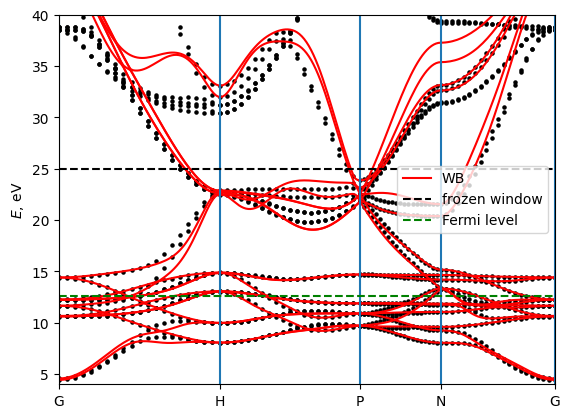

In [24]:

# plot the bands and compare with pw
# EF = 12

A = np.loadtxt("./pwscf/Fe_bands_pw.dat")
bohr_ang = scipy.constants.physical_constants['Bohr radius'][0] / 1e-10
alatt = 5.4235* bohr_ang
A[:,0]*= 2*np.pi/alatt
A[:,1] = A[:,1] 
plt.scatter(A[:,0], A[:,1], c="black", s=5)

    

bands_path.plot_path_fat(path,
                quantity=None,
                # save_file="Fe_bands.pdf",
                Eshift=0,
                Emin=-10, Emax=50,
                iband=None,
                mode="fatband",
                fatfactor=20,
                cut_k=False,
                linecolor="red",
                close_fig=False,
                show_fig=False,
                label=f"WB"
                )

plt.ylim(4, 40)
plt.hlines(froz_max, 0, A[-1,0], linestyles="dashed", label="frozen window", color="black")
plt.hlines(12.6, 0, A[-1,0], linestyles="dashed", label="Fermi level", color="green")
plt.legend()
plt.savefig("Fe_bands.pdf")


## 8. AHC and Ohmic conductivity

### 8.1 calculate 

In [25]:
results_grid = {}
efermi = np.linspace(12.4,12.8,1001)
param = dict(Efermi=efermi)
calculators_grid = {
     "CDOS": wb.calculators.static.CumDOS(**param),
                "ohmic": wb.calculators.static.Ohmic_FermiSea(**param),
                "ahc_internal": wb.calculators.static.AHC(kwargs_formula={"external_terms":False}, **param),
            "ahc_external": wb.calculators.static.AHC(kwargs_formula={"internal_terms":False}, **param ),	
}

grid =  wb.Grid(system, NKFFT=6, NK=48)

result_grid = wb.run(system, 
                     grid, 
                     calculators_grid, 
                    fout_name="Fe_grid",
                    adpt_num_iter=0,
                    symmetrize=False,  # we do not symmetrize here so that we can check how symmetric are the WFs
                    use_irred_kpt=False,
                    )


# plot the bands to compare with pw





Starting run()
Using the follwing calculators : 
############################################################

 'CDOS'  :  <wannierberri.calculators.static.CumDOS object at 0x79a6b8fe39b0>  : Cumulative density of states
 'ohmic'  :  <wannierberri.calculators.static.Ohmic_FermiSea object at 0x79a6b8fe3f80>  : Ohmic conductivity (:math:`S/m`)

        | With Fermi sea integral. Eq(31) in `Ref <https://www.nature.com/articles/s41524-021-00498-5>`__
        | Output: :math:`\sigma_{\alpha\beta} = e^2/\hbar \tau \int [dk] \partial_\beta v_\alpha f`for \tau=1fs| Instruction: :math:`j_\alpha = \sigma_{\alpha\beta} E_\beta`
 'ahc_internal'  :  <wannierberri.calculators.static.AHC object at 0x79a6b90a15e0>  : Anomalous Hall conductivity (:math:`s^3 \cdot A^2 / (kg \cdot m^3) = S/m`)

        | With Fermi sea integral Eq(11) in `Ref <https://www.nature.com/articles/s41524-021-00498-5>`__
        | Output: :math:`O = -e^2/\hbar \int [dk] \Omega f`
        | Instruction: :math:`j_\alpha = \sigma_

                  88              5.4                  26.0                  31.4
                 176             10.6                  20.3                  31.0
                 264             15.7                  14.8                  30.5
                 352             20.8                   9.5                  30.3
                 440             25.9                   4.2                  30.2
time for processing    512 K-points on   8 processes:    30.2697 ; per K-point          0.0591 ; proc-sec per K-point          0.4730
time1 =  4.76837158203125e-07
Totally processed 512 K-points 
run() finished


### 8.2 Plot 

/tmp/ipykernel_108701/1474735278.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


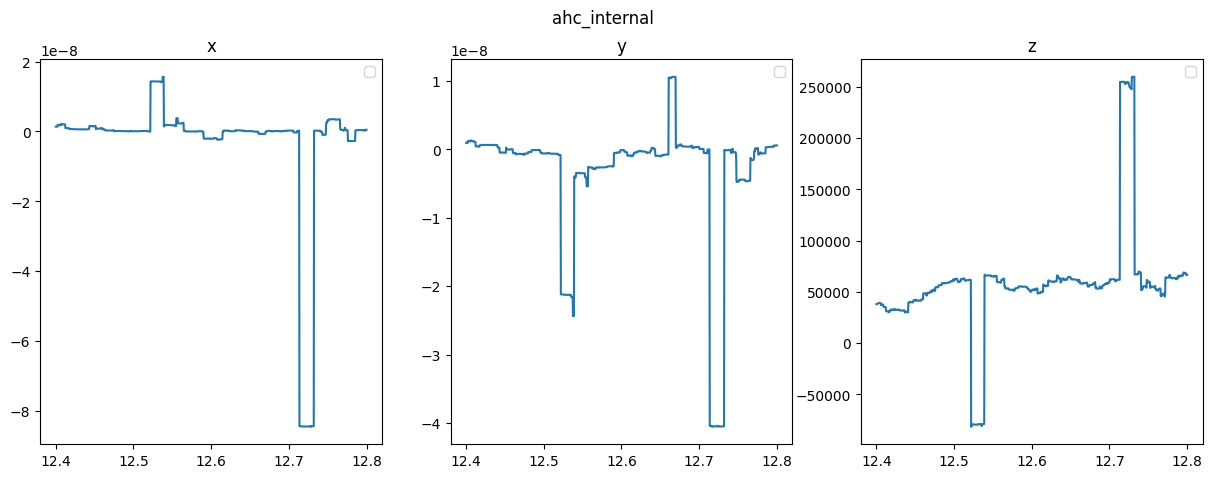

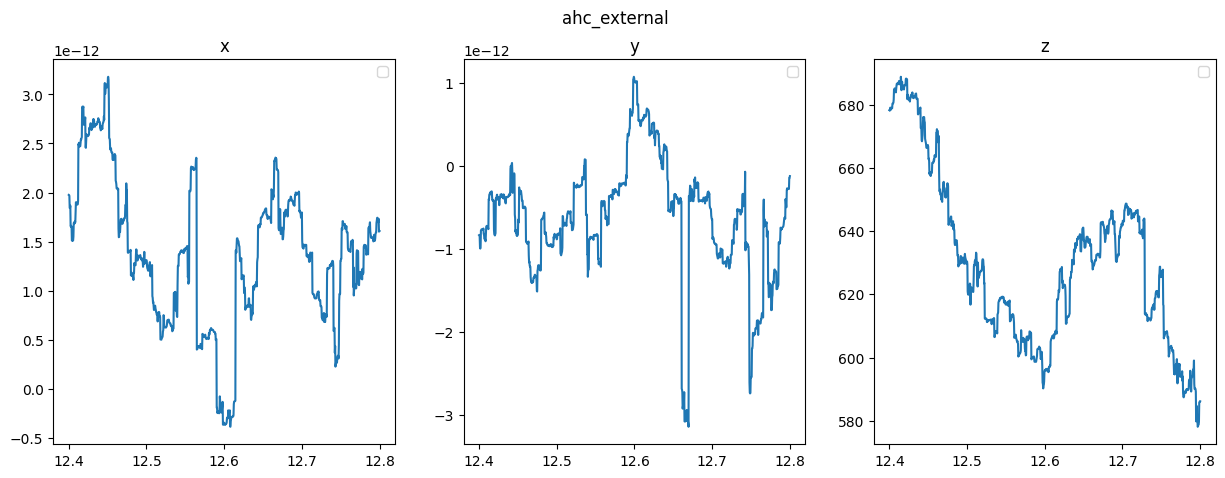

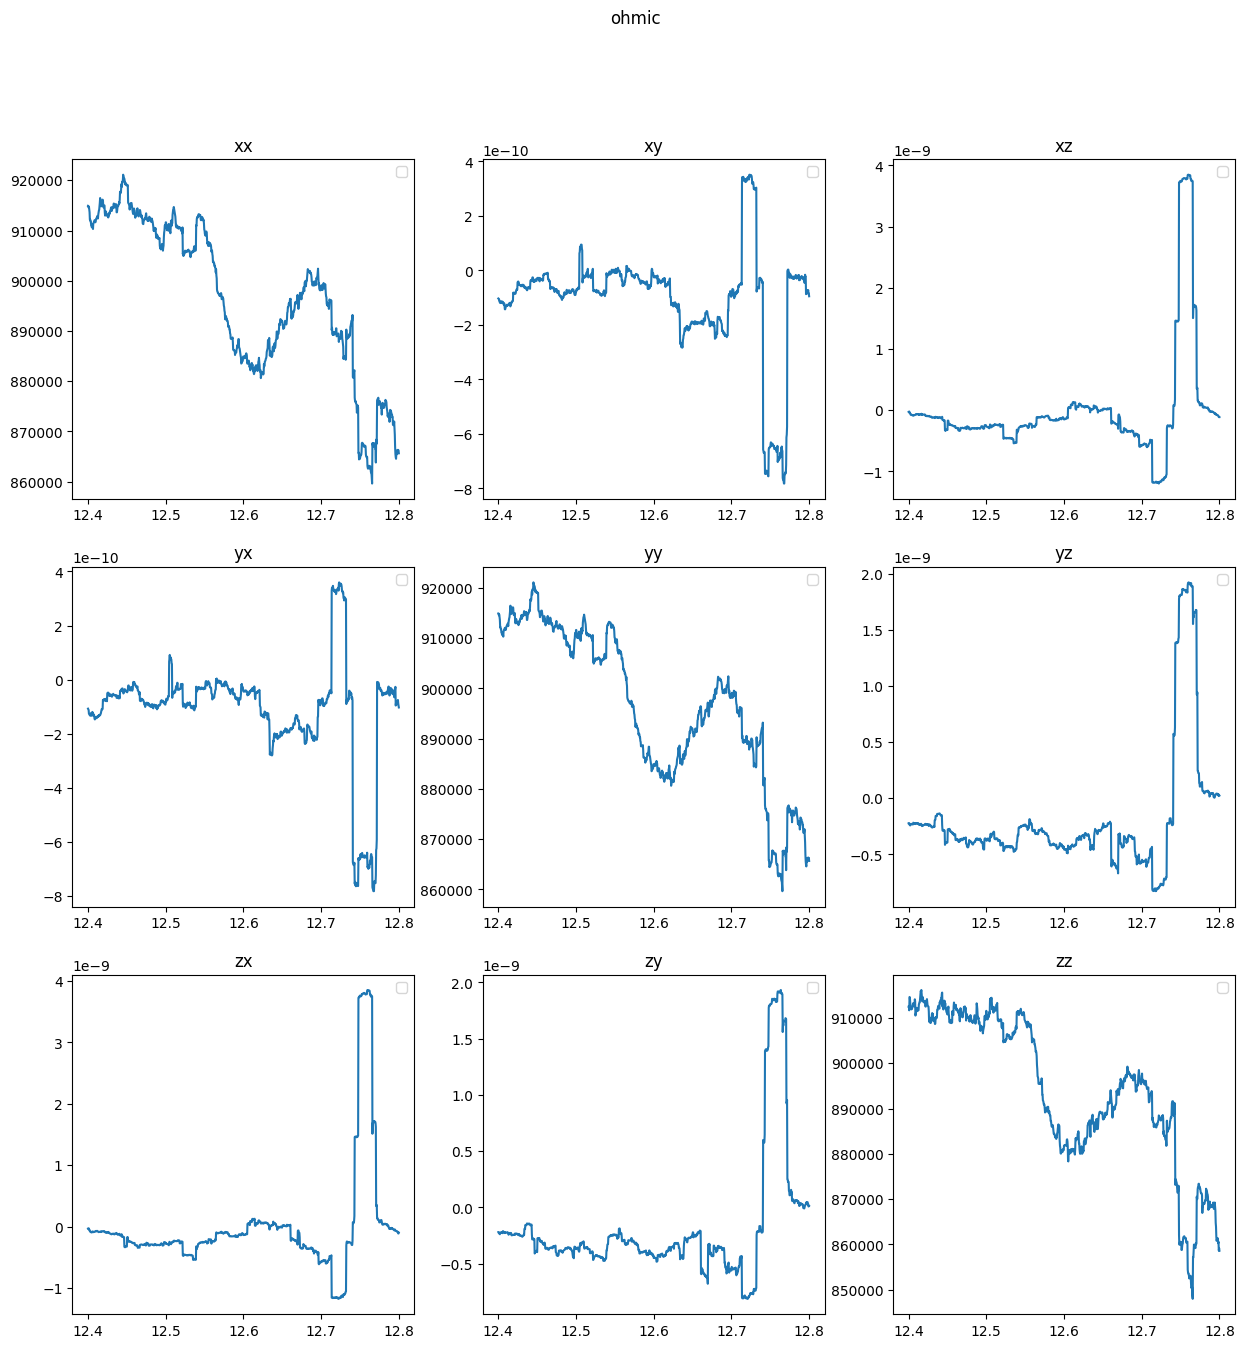

In [26]:
def plotxyz(axes, x, data, pre = "", label="",ls="-"):
    for i in range(3):
        ax =axes[i]
        ax.plot(x, data[:,i], ls, label=label)
        ax.set_title(f"{pre}{'xyz'[i]}")



quantities =  ["ahc_internal", "ahc_external","ohmic"]
    
nfig = len(quantities)
for quantity in quantities:
    fig = None
    res = result_grid.results[quantity]
    data = res.data
    E = res.Energies[0]
    if fig is None:
        if data.ndim == 2:
            nfigx = 1
            nfigy = data.shape[1]
        elif data.ndim == 3:
            nfigx = data.shape[1]
            nfigy = data.shape[2]
        fig, axes = plt.subplots(nfigx, nfigy, figsize=(5*nfigy,5*nfigx))
    if nfigx ==1:
        plotxyz(axes, E, data)
    else:
        for i in range(nfigx):
            plotxyz(axes[i], E, data[:,i], pre="xyz"[i], )
    for ax in axes.flat:
        ax.legend()
    fig.suptitle(quantity)
    plt.show()
    plt.close()
    
        
